# 02. Velocity diagnostics and STAMPS validation

This notebook is a post-processing notebook.
It assumes the upstream processing has already produced velocity products and related metadata.
The notebook then does four things:

- render spatial maps for deformation velocity and velocity stability
- render acquisition-axis trend plots for selected persistent scatterers
- compute summary statistics for pySTAMPS and STAMPS
- compute matched-point validation metrics against the STAMPS baseline

## What this notebook expects

The processed folders should already contain the logical arrays needed for diagnostics.
The physical file format can be MATLAB, HDF5, pickle, NumPy, or another container, but the notebook API needs these arrays:

- PS coordinates `lonlat`
- acquisition times `day` and the master index
- velocity field `v`
- velocity stability field `vs`
- optional coherence for masking

In the current packaged tutorial datasets, those arrays are read from `ps2.mat`, `mv2.mat`, `mean_v.mat`, `scla2.mat`, and optionally `pm2.mat`.

Naming follows the StaMPS convention:

- if Step 8 is applied, use `v-dos` and `vs-dos`
- if Step 8 is not applied, use `v-do` and `vs-do`

In [1]:
from __future__ import annotations

from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pystamps.notebooks import (
    build_comparison_masks,
    build_velocity_report,
    export_diagnostics_report,
    fitted_velocity_series,
    hist_compare,
    load_velocity_diagnostics,
    match_diagnostic_points,
    plot_mode_from_step8,
    plot_name,
    scatter_compare,
    select_diagnostic_indices,
    select_points,
    stability_series,
)

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(suppress=True, precision=4)
pd.options.display.max_columns = 20

RUN_ROOT = Path('inputs_and_outputs/InSAR_dataset_test_stage8diag')
STAMPS_ROOT = Path('inputs_and_outputs/InSAR_dataset_test_stage8diag_hl')

APPLY_STEP8 = True
PLOT_MODE_OVERRIDE = 'auto'
PLOT_MODE = plot_mode_from_step8(APPLY_STEP8, PLOT_MODE_OVERRIDE)

CMAP_V = 'RdBu_r'
CMAP_VS = 'magma'
V_RANGE = None
VS_RANGE = None

PLOT_TS_POINTS = 6
TS_SELECTION_RULES = ('high_velocity', 'high_variance')

COMPUTE_PERCENTILES = True
PERCENTILES = (5.0, 95.0)
OUTLIER_FILTER = 'none'

COMPARE_WITH_STAMPS = True
COMPARISON_METRICS = ('RMSE', 'MAE', 'bias')
MATCH_DECIMALS = 10

COHERENCE_THRESHOLD = None
MASKING_STRATEGY = 'none'

EXPORT_DIAGNOSTICS = True
EXPORT_DIR = Path('tmp/notebook2_diagnostics')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

parameter_rows = [
    {'group': 'data', 'name': 'pySTAMPS_dataset', 'value': RUN_ROOT.name},
    {'group': 'data', 'name': 'stamps_dataset', 'value': STAMPS_ROOT.name},
    {'group': 'processing', 'name': 'apply_step8', 'value': APPLY_STEP8},
    {'group': 'processing', 'name': 'plot_mode', 'value': PLOT_MODE},
    {'group': 'plots', 'name': 'cmap_v', 'value': CMAP_V},
    {'group': 'plots', 'name': 'cmap_vs', 'value': CMAP_VS},
    {'group': 'plots', 'name': 'v_range', 'value': V_RANGE},
    {'group': 'plots', 'name': 'vs_range', 'value': VS_RANGE},
    {'group': 'plots', 'name': 'plot_ts_points', 'value': PLOT_TS_POINTS},
    {'group': 'plots', 'name': 'ts_selection_rules', 'value': ', '.join(TS_SELECTION_RULES)},
    {'group': 'statistics', 'name': 'compute_percentiles', 'value': COMPUTE_PERCENTILES},
    {'group': 'statistics', 'name': 'percentiles', 'value': PERCENTILES},
    {'group': 'statistics', 'name': 'outlier_filter', 'value': OUTLIER_FILTER},
    {'group': 'comparison', 'name': 'compare_with_stamps', 'value': COMPARE_WITH_STAMPS},
    {'group': 'comparison', 'name': 'comparison_metrics', 'value': ', '.join(COMPARISON_METRICS)},
    {'group': 'comparison', 'name': 'match_decimals', 'value': MATCH_DECIMALS},
    {'group': 'selection', 'name': 'coherence_threshold', 'value': COHERENCE_THRESHOLD},
    {'group': 'selection', 'name': 'masking_strategy', 'value': MASKING_STRATEGY},
    {'group': 'export', 'name': 'export_diagnostics', 'value': EXPORT_DIAGNOSTICS},
    {'group': 'export', 'name': 'export_dir', 'value': EXPORT_DIR.name},
]

display(pd.DataFrame(parameter_rows))

,group,name,value
0,data,pySTAMPS_dataset,InSAR_dataset_test_stage8diag
1,data,stamps_dataset,InSAR_dataset_test_stage8diag_hl
2,processing,apply_step8,True
3,processing,plot_mode,dos
4,plots,cmap_v,RdBu_r
5,plots,cmap_vs,magma
6,plots,v_range,None
7,plots,vs_range,None
8,plots,plot_ts_points,6
9,plots,ts_selection_rules,"high_velocity, high_variance"


## How the diagnostics are computed

The notebook uses the packaged helper API so the logic stays outside the notebook.

- `v-*` is read from `mv2.mean_v` when available.
- `vs-*` first tries `mv2.mean_v_std`.
  If that field is empty or all zeros, the notebook falls back to `abs(C_ps_uw)` from `scla2.mat` and labels it as a stability proxy.
- Coherence masking is lazy. If no coherence threshold is requested, `pm2.mat` is not loaded.
- Validation metrics are computed only on the matched PS subset obtained by aligning pySTAMPS and STAMPS on rounded `lonlat` coordinates.

This is important here because the pySTAMPS tutorial run is a subset of the much denser STAMPS cloud.

In [2]:
def combined_limits(run_values, stamps_values=None, *, override=None):
    if override is not None:
        low, high = override
        return float(low), float(high)

    arrays = []
    run_values = np.asarray(run_values, dtype=float).reshape(-1)
    run_values = run_values[np.isfinite(run_values)]
    if run_values.size:
        arrays.append(run_values)

    if stamps_values is not None:
        stamps_values = np.asarray(stamps_values, dtype=float).reshape(-1)
        stamps_values = stamps_values[np.isfinite(stamps_values)]
        if stamps_values.size:
            arrays.append(stamps_values)

    if not arrays:
        return None, None

    combined = np.concatenate(arrays)
    low, high = np.nanpercentile(combined, [2.0, 98.0])
    if not np.isfinite(low) or not np.isfinite(high):
        return None, None
    if low == high:
        margin = 1.0 if low == 0 else abs(low) * 0.05
        low -= margin
        high += margin
    return float(low), float(high)


def save_diagnostics_figure(fig, stem):
    if not EXPORT_DIAGNOSTICS:
        return None
    target = EXPORT_DIR / f'{stem}.png'
    fig.savefig(target, dpi=160, bbox_inches='tight')
    return target


run_diag = load_velocity_diagnostics(
    RUN_ROOT,
    apply_step8=APPLY_STEP8,
    plot_mode=PLOT_MODE,
    load_coherence=COHERENCE_THRESHOLD is not None or MASKING_STRATEGY != 'none',
)
stamps_diag = (
    load_velocity_diagnostics(
        STAMPS_ROOT,
        apply_step8=APPLY_STEP8,
        plot_mode=PLOT_MODE,
        load_coherence=COHERENCE_THRESHOLD is not None or MASKING_STRATEGY != 'none',
    )
    if COMPARE_WITH_STAMPS
    else None
)
run_mask, stamps_mask = build_comparison_masks(
    run_diag,
    stamps_diag,
    coherence_threshold=COHERENCE_THRESHOLD,
    masking_strategy=MASKING_STRATEGY,
)
matched = match_diagnostic_points(
    run_diag,
    stamps_diag,
    run_mask=run_mask,
    stamps_mask=stamps_mask,
    decimals=MATCH_DECIMALS,
)

matched_run_mask = np.zeros(run_diag.velocity.size, dtype=bool)
matched_run_mask[matched.run_indices] = True
matched_stamps_mask = None
stamps_index_map = {}
if stamps_diag is not None:
    matched_stamps_mask = np.zeros(stamps_diag.velocity.size, dtype=bool)
    matched_stamps_mask[matched.stamps_indices] = True
    stamps_index_map = {int(run_ix): int(stamps_ix) for run_ix, stamps_ix in zip(matched.run_indices, matched.stamps_indices, strict=False)}

source_rows = [
    {'dataset': 'pySTAMPS', 'field': plot_name('v', run_diag.plot_mode), 'source': run_diag.velocity_source},
    {'dataset': 'pySTAMPS', 'field': plot_name('vs', run_diag.plot_mode), 'source': run_diag.stability_source},
]
if stamps_diag is not None:
    source_rows.extend(
        [
            {'dataset': 'STAMPS', 'field': plot_name('v', stamps_diag.plot_mode), 'source': stamps_diag.velocity_source},
            {'dataset': 'STAMPS', 'field': plot_name('vs', stamps_diag.plot_mode), 'source': stamps_diag.stability_source},
        ]
    )

alignment_rows = [
    {'metric': 'pySTAMPS masked PS', 'value': int(np.count_nonzero(run_mask))},
    {'metric': 'STAMPS masked PS', 'value': int(np.count_nonzero(stamps_mask)) if stamps_mask is not None else 0},
    {'metric': 'matched PS for validation', 'value': int(matched.run_indices.size)},
    {'metric': 'matching rule', 'value': f'lonlat rounded to {MATCH_DECIMALS} decimals'},
]

display(pd.DataFrame(source_rows))
display(pd.DataFrame(alignment_rows))

report = build_velocity_report(
    run_diag,
    stamps_diag,
    run_mask=run_mask,
    stamps_mask=stamps_mask,
    compute_percentiles=COMPUTE_PERCENTILES,
    percentiles=PERCENTILES,
    outlier_filter=OUTLIER_FILTER,
    comparison_metrics=COMPARISON_METRICS,
)
stats_df = pd.DataFrame(report['stats_rows'])
comparison_df = pd.DataFrame(report['comparison_rows'])

display(stats_df)
if not comparison_df.empty:
    display(comparison_df)

print(report['summary'])

if EXPORT_DIAGNOSTICS:
    exported = export_diagnostics_report(report, EXPORT_DIR)
    print('Exported report files:', ', '.join(path.name for path in exported.values()))

,dataset,field,source
0,pySTAMPS,v-dos,mv2.mean_v
1,pySTAMPS,vs-dos,mv2.mean_v_std
2,STAMPS,v-dos,mv2.mean_v
3,STAMPS,vs-dos,abs(scla2.C_ps_uw) stability proxy


,metric,value
0,pySTAMPS masked PS,69009
1,STAMPS masked PS,587320
2,matched PS for validation,69009
3,matching rule,lonlat rounded to 10 decimals


,dataset,field,source,count,mean,min,max,std,p5,p95
0,pySTAMPS,v-dos,mv2.mean_v,69009.0,-0.075184,-20.266275,22.874037,1.405616,-2.257663,2.091405
1,pySTAMPS,vs-dos,mv2.mean_v_std,69009.0,0.651172,0.310216,2.644497,0.186812,0.445121,1.020352
2,STAMPS,v-dos,mv2.mean_v,587320.0,-0.002191,-0.086832,0.080083,0.017230,-0.031520,0.024892
3,STAMPS,vs-dos,abs(scla2.C_ps_uw) stability proxy,587320.0,6.366597,0.000004,39.343601,4.734596,0.518748,15.448322


,field,alignment,count,bias,rmse,mae,interpretation
0,v-dos,lonlat@10dp,69009.0,-0.080132,1.408384,1.015108,strong systematic bias; broad disagreement rel...
1,vs-dos,lonlat@10dp,69009.0,-5.010421,6.573418,5.059947,strong systematic bias; broad disagreement rel...


plot mode: dos
pySTAMPS velocity source: mv2.mean_v
pySTAMPS stability source: mv2.mean_v_std
matched comparison subset: 69009 PS aligned by lon/lat rounded to 10 decimals
v-dos: bias=-0.0801322 rmse=1.40838 compared on 69009 PS
v-dos interpretation: strong systematic bias; broad disagreement relative to the STAMPS spread
vs-dos: bias=-5.01042 rmse=6.57342 compared on 69009 PS
vs-dos interpretation: strong systematic bias; broad disagreement relative to the STAMPS spread


Exported report files: velocity_stats.csv, velocity_comparison.csv, velocity_summary.json


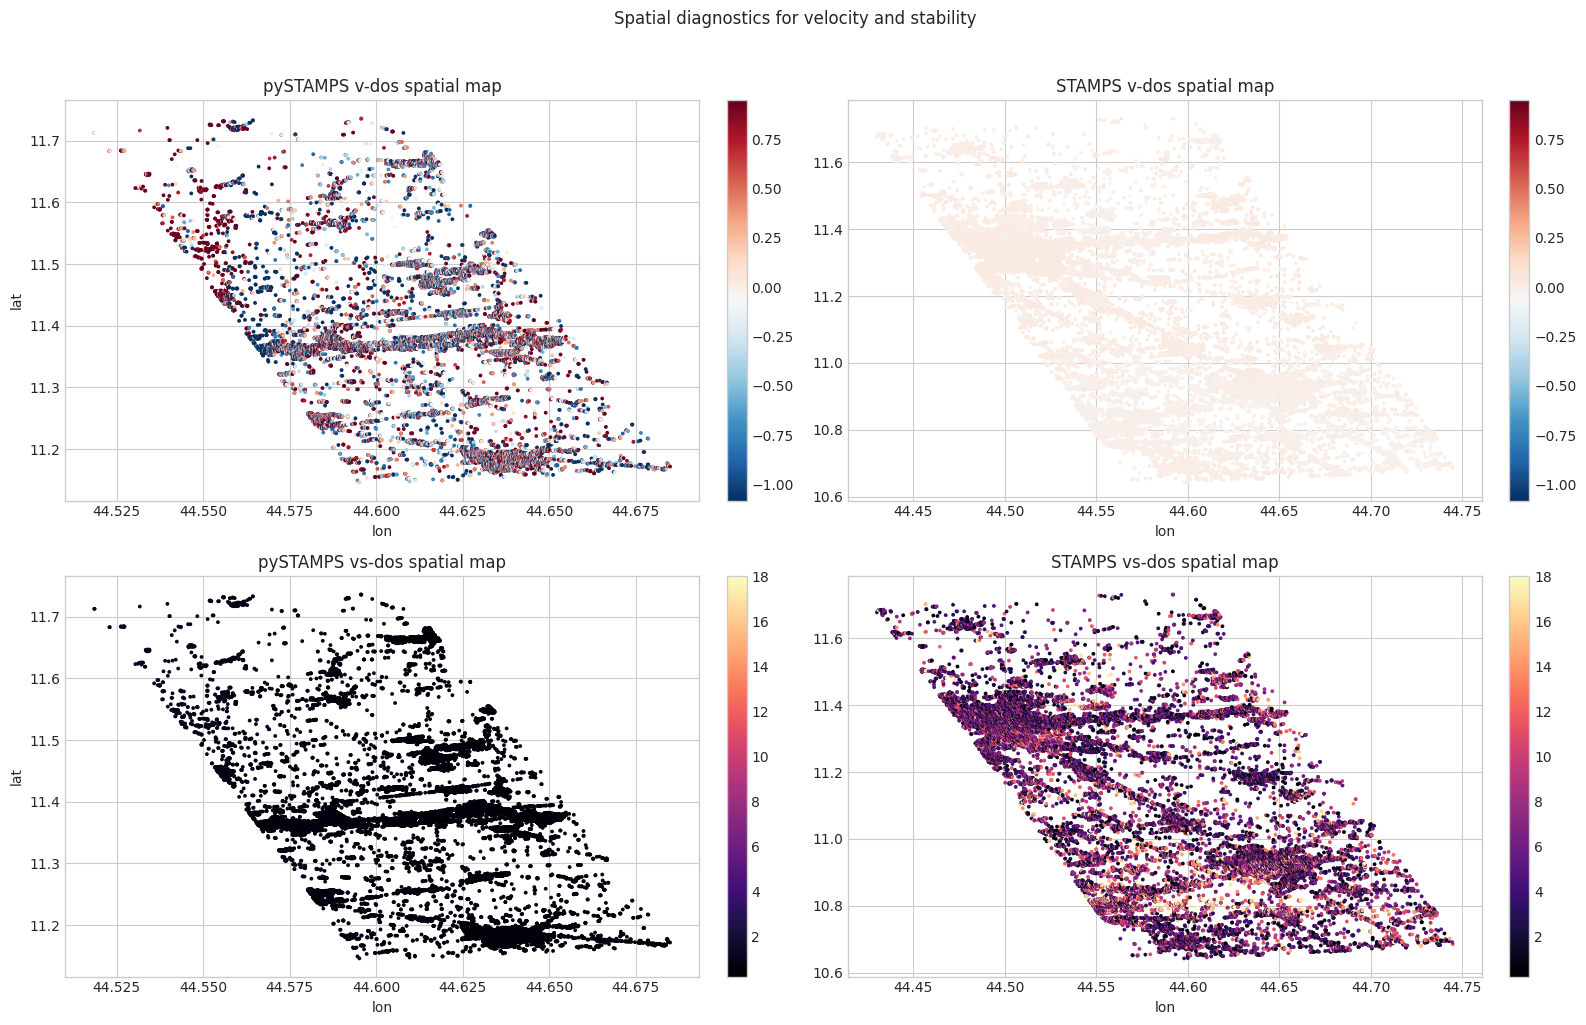

In [3]:
run_velocity_points = select_points(run_diag.lonlat, np.flatnonzero(run_mask))
run_velocity_values = run_diag.velocity[run_mask]
run_stability_points = select_points(run_diag.lonlat, np.flatnonzero(run_mask))
run_stability_values = run_diag.stability[run_mask]

if stamps_diag is not None and stamps_mask is not None:
    stamps_velocity_points = select_points(stamps_diag.lonlat, np.flatnonzero(stamps_mask))
    stamps_velocity_values = stamps_diag.velocity[stamps_mask]
    stamps_stability_points = select_points(stamps_diag.lonlat, np.flatnonzero(stamps_mask))
    stamps_stability_values = stamps_diag.stability[stamps_mask]
else:
    stamps_velocity_points = np.empty((0, 2), dtype=float)
    stamps_velocity_values = np.empty((0,), dtype=float)
    stamps_stability_points = np.empty((0, 2), dtype=float)
    stamps_stability_values = np.empty((0,), dtype=float)

v_limits = combined_limits(run_velocity_values, stamps_velocity_values, override=V_RANGE)
vs_limits = combined_limits(run_stability_values, stamps_stability_values, override=VS_RANGE)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
scatter_compare(
    axes[0, 0],
    axes[0, 1],
    run_velocity_points,
    run_velocity_values,
    stamps_velocity_points,
    stamps_velocity_values,
    f"{plot_name('v', PLOT_MODE)} spatial map",
    cmap=CMAP_V,
    vmin=v_limits[0],
    vmax=v_limits[1],
)
scatter_compare(
    axes[1, 0],
    axes[1, 1],
    run_stability_points,
    run_stability_values,
    stamps_stability_points,
    stamps_stability_values,
    f"{plot_name('vs', PLOT_MODE)} spatial map",
    cmap=CMAP_VS,
    vmin=vs_limits[0],
    vmax=vs_limits[1],
)
fig.suptitle('Spatial diagnostics for velocity and stability', y=1.02)
plt.tight_layout()
save_diagnostics_figure(fig, f'spatial_diagnostics_{PLOT_MODE}')
plt.show()

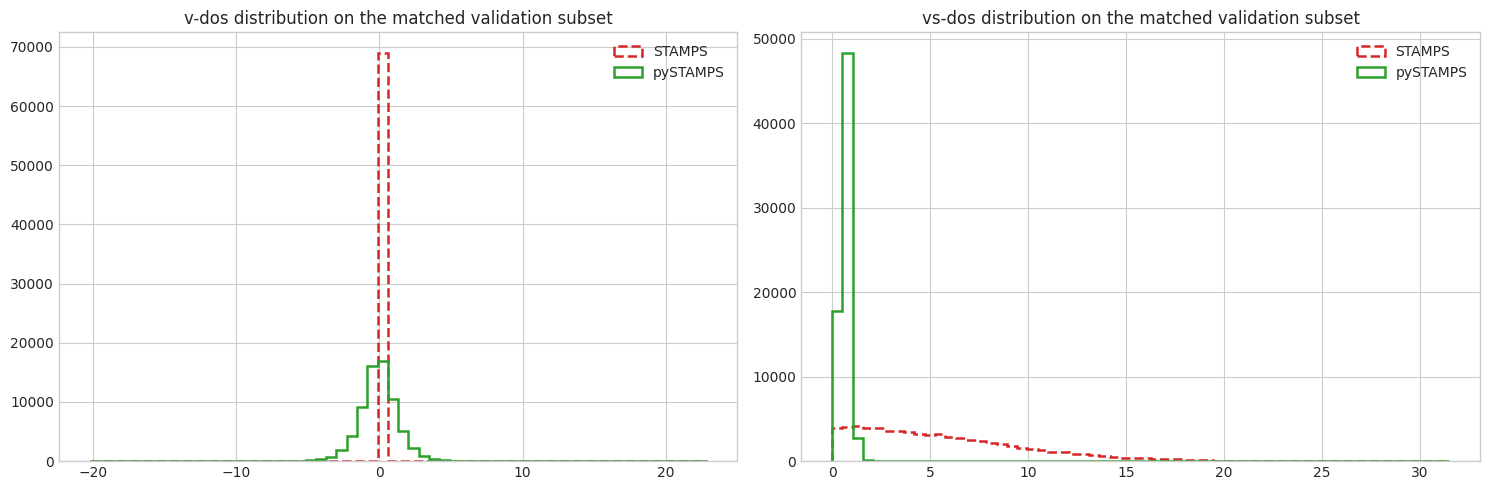

In [4]:
run_hist_velocity = run_diag.velocity[matched.run_indices] if matched.run_indices.size else run_diag.velocity[run_mask]
run_hist_stability = run_diag.stability[matched.run_indices] if matched.run_indices.size else run_diag.stability[run_mask]
stamps_hist_velocity = (
    stamps_diag.velocity[matched.stamps_indices]
    if stamps_diag is not None and matched.stamps_indices.size
    else np.empty((0,), dtype=float)
)
stamps_hist_stability = (
    stamps_diag.stability[matched.stamps_indices]
    if stamps_diag is not None and matched.stamps_indices.size
    else np.empty((0,), dtype=float)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
hist_compare(
    axes[0],
    run_hist_velocity,
    stamps_hist_velocity,
    f"{plot_name('v', PLOT_MODE)} distribution on the matched validation subset",
)
hist_compare(
    axes[1],
    run_hist_stability,
    stamps_hist_stability,
    f"{plot_name('vs', PLOT_MODE)} distribution on the matched validation subset",
)
plt.tight_layout()
save_diagnostics_figure(fig, f'distribution_diagnostics_{PLOT_MODE}')
plt.show()

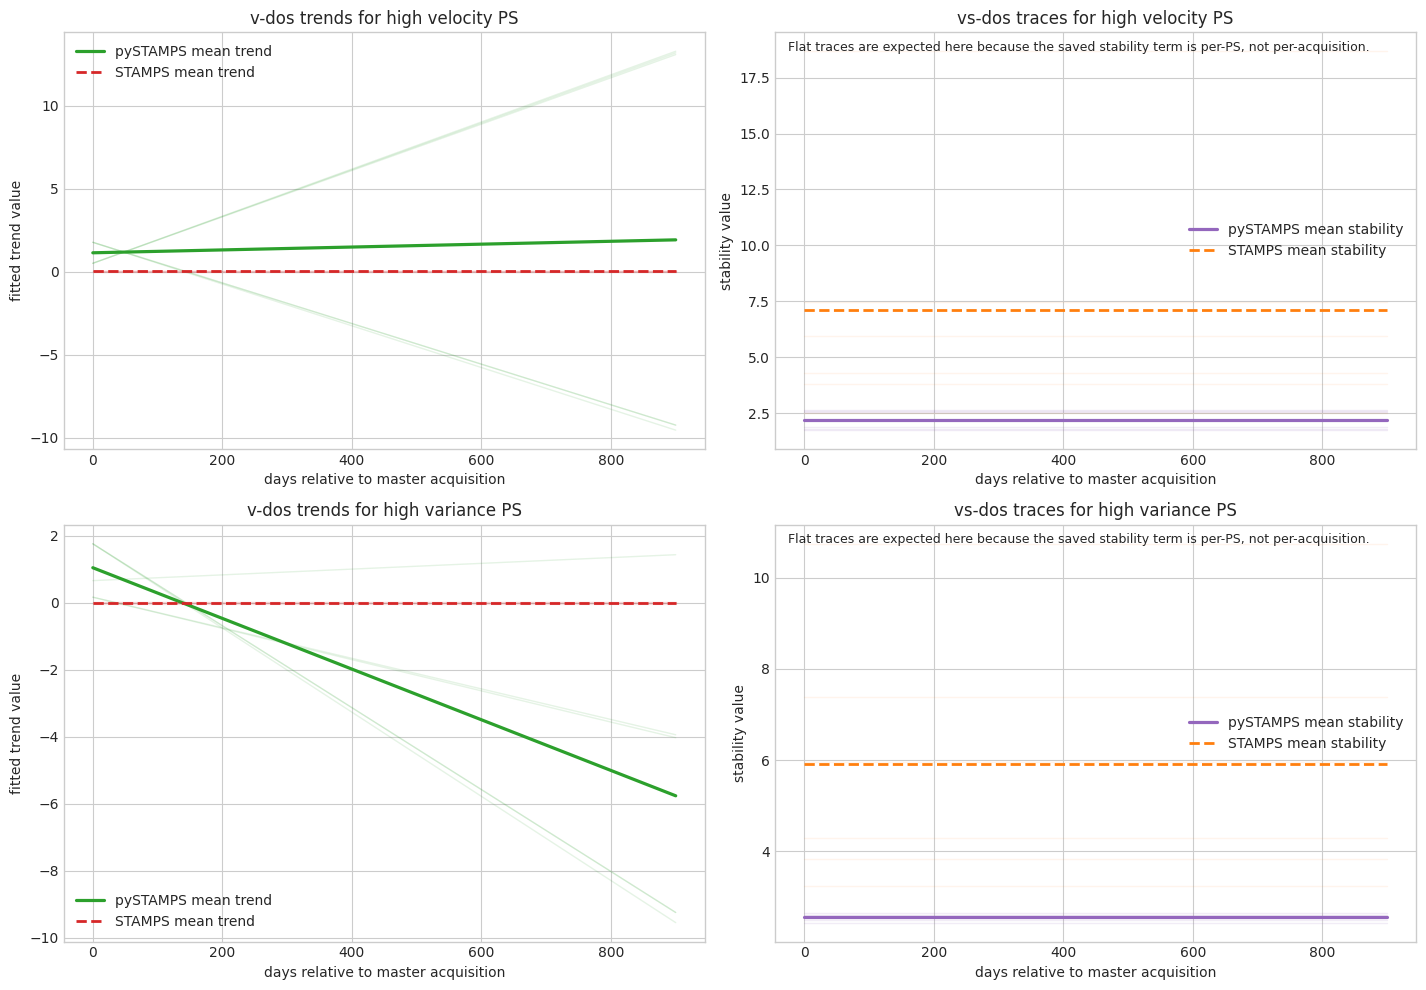

In [5]:
selection_rules = tuple(dict.fromkeys(TS_SELECTION_RULES))
selection_mask = matched_run_mask if matched.run_indices.size else run_mask
fig, axes = plt.subplots(len(selection_rules), 2, figsize=(15, 5 * len(selection_rules)), squeeze=False)

for row, rule in enumerate(selection_rules):
    selection_values = run_diag.velocity if rule == 'high_velocity' else run_diag.stability
    selected_run_ix = select_diagnostic_indices(selection_values, mask=selection_mask, rule=rule, count=PLOT_TS_POINTS)
    selected_stamps_ix = np.array([stamps_index_map[ix] for ix in selected_run_ix if ix in stamps_index_map], dtype=int)

    ax_velocity = axes[row, 0]
    run_velocity_ts = fitted_velocity_series(run_diag, selected_run_ix)
    if run_velocity_ts.size:
        ax_velocity.plot(run_diag.time_axis_days, run_velocity_ts.T, color='tab:green', alpha=0.12, linewidth=1.0)
        ax_velocity.plot(
            run_diag.time_axis_days,
            run_velocity_ts.mean(axis=0),
            color='tab:green',
            linewidth=2.3,
            label='pySTAMPS mean trend',
        )
    if stamps_diag is not None and selected_stamps_ix.size:
        stamps_velocity_ts = fitted_velocity_series(stamps_diag, selected_stamps_ix)
        if stamps_velocity_ts.size:
            ax_velocity.plot(stamps_diag.time_axis_days, stamps_velocity_ts.T, color='tab:red', alpha=0.08, linewidth=1.0)
            ax_velocity.plot(
                stamps_diag.time_axis_days,
                stamps_velocity_ts.mean(axis=0),
                color='tab:red',
                linestyle='--',
                linewidth=2.0,
                label='STAMPS mean trend',
            )
    ax_velocity.set_title(f"{plot_name('v', PLOT_MODE)} trends for {rule.replace('_', ' ')} PS")
    ax_velocity.set_xlabel('days relative to master acquisition')
    ax_velocity.set_ylabel('fitted trend value')
    ax_velocity.legend()

    ax_stability = axes[row, 1]
    run_stability_ts = stability_series(run_diag, selected_run_ix)
    if run_stability_ts.size:
        ax_stability.plot(run_diag.time_axis_days, run_stability_ts.T, color='tab:purple', alpha=0.12, linewidth=1.0)
        ax_stability.plot(
            run_diag.time_axis_days,
            run_stability_ts.mean(axis=0),
            color='tab:purple',
            linewidth=2.3,
            label='pySTAMPS mean stability',
        )
    if stamps_diag is not None and selected_stamps_ix.size:
        stamps_stability_ts = stability_series(stamps_diag, selected_stamps_ix)
        if stamps_stability_ts.size:
            ax_stability.plot(stamps_diag.time_axis_days, stamps_stability_ts.T, color='tab:orange', alpha=0.08, linewidth=1.0)
            ax_stability.plot(
                stamps_diag.time_axis_days,
                stamps_stability_ts.mean(axis=0),
                color='tab:orange',
                linestyle='--',
                linewidth=2.0,
                label='STAMPS mean stability',
            )
    if 'proxy' in run_diag.stability_source.lower() or (stamps_diag is not None and 'proxy' in stamps_diag.stability_source.lower()):
        ax_stability.text(
            0.02,
            0.98,
            'Flat traces are expected here because the saved stability term is per-PS, not per-acquisition.',
            transform=ax_stability.transAxes,
            va='top',
            ha='left',
            fontsize=9,
        )
    ax_stability.set_title(f"{plot_name('vs', PLOT_MODE)} traces for {rule.replace('_', ' ')} PS")
    ax_stability.set_xlabel('days relative to master acquisition')
    ax_stability.set_ylabel('stability value')
    ax_stability.legend()

plt.tight_layout()
save_diagnostics_figure(fig, f'time_series_diagnostics_{PLOT_MODE}')
plt.show()

## How to reuse this notebook

Change only the parameter block at the top.
If your own workflow stores the same logical arrays in another format, adapt the loader in the package API rather than rewriting the notebook cells.